# Irreducible mass of Black Holes

Rotating BH have a irreducible mass wich is function of the gravitational mass due to Penrose process. The relation between the two can be written as:
$$
M_{irr} = M f(\chi) = M \sqrt{\frac{1 + \sqrt{1 - \chi^2 }}{2}}
$$
We procede normalizing at 1 the true value.

In [94]:
mu = 1.0
sigma = 0.2

In [95]:
import numpy as np
import scipy.stats as stats
import matplotlib.pyplot as plt
import astropy.visualization.hist as hist


In [96]:
def f_chi(x):
    return 1/(np.sqrt(2*np.pi)*sigma) * np.exp(-(x-mu)**2/(2*sigma**2))

def Mirr(M, chi):
    return M * np.sqrt(0.5*(1+np.sqrt(1-chi**2)))

(0.0, 2.0)

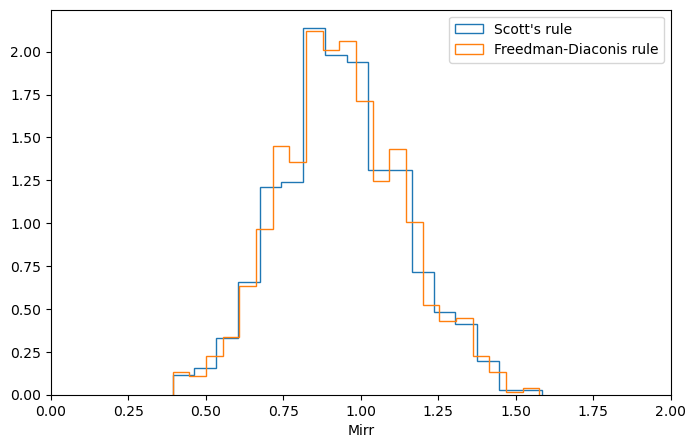

In [97]:
nsample = 1000

chi_sample = np.random.uniform(0,1, nsample)
M_sample = np.random.normal(mu, sigma, nsample)

Mirr_sample = np.zeros(nsample)
for i in range(nsample): Mirr_sample[i] = M_sample[i]*np.sqrt(0.5*(1+np.sqrt(1-chi_sample[i]**2)))

plt.figure(figsize=(8, 5))
hist(Mirr_sample, bins="scott", histtype="step",density=True, label="Scott's rule")
hist(Mirr_sample, bins="freedman", histtype="step",density=True, label="Freedman-Diaconis rule")
plt.xlabel("Mirr")
plt.legend()

plt.xlim(0,2)

In [98]:
from sklearn.neighbors import KernelDensity

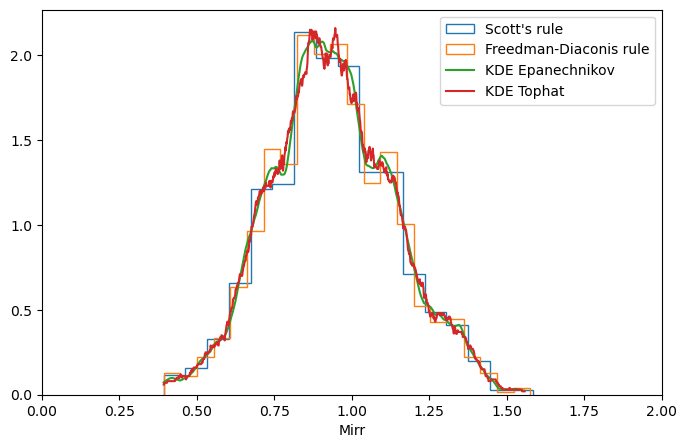

In [99]:
bandwidth = 0.05

kde_epanechnikov = KernelDensity(bandwidth=bandwidth, kernel="epanechnikov")
kde_tophat = KernelDensity(bandwidth=bandwidth, kernel="tophat")

kde_epanechnikov.fit(Mirr_sample[:, np.newaxis])
kde_tophat.fit(Mirr_sample[:, np.newaxis])

xgrid = np.linspace(Mirr_sample.min(), Mirr_sample.max(), 1000)

pdf_epanechnikov = np.exp(kde_epanechnikov.score_samples(xgrid[:, np.newaxis]))
pdf_tophat = np.exp(kde_tophat.score_samples(xgrid[:, np.newaxis]))

plt.figure(figsize=(8, 5))
hist(Mirr_sample, bins="scott", histtype="step",density=True, label="Scott's rule")
hist(Mirr_sample, bins="freedman", histtype="step",density=True, label="Freedman-Diaconis rule")
plt.plot(xgrid, pdf_epanechnikov, "-", label="KDE Epanechnikov")
plt.plot(xgrid, pdf_tophat, "-", label="KDE Tophat")
plt.xlim(0,2)
plt.xlabel("Mirr")
plt.legend()
plt.show()

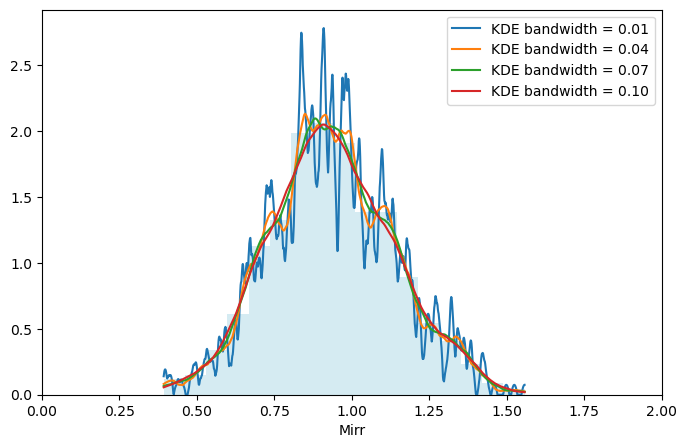

In [100]:
range_bandwidth = np.arange(0.01, 0.1, 0.03)

pdf_list = []

for bandwidth in range_bandwidth:
    kde_epanechnikov = KernelDensity(bandwidth=bandwidth, kernel="epanechnikov")

    kde_epanechnikov.fit(Mirr_sample[:, np.newaxis])

    xgrid = np.linspace(Mirr_sample.min(), Mirr_sample.max(), 1000)

    pdf_epanechnikov = np.exp(kde_epanechnikov.score_samples(xgrid[:, np.newaxis]))

    pdf_list.append((bandwidth, pdf_epanechnikov))

plt.figure(figsize=(8, 5))
plt.hist(Mirr_sample, bins="scott", density=True, color="lightblue", alpha=0.5)
for bandwidth, pdf in pdf_list:
    plt.plot(xgrid, pdf, "-", label="KDE bandwidth = {:.2f}".format(bandwidth))
plt.xlim(0, 2)
plt.xlabel("Mirr")
plt.legend()

### KS test